# 1. Chrome-Dino Game Overview: 🦖 🦕

It is a classical game that was developed by Sebastien Gabriel, Alan Bettes, and Edward Jung in 2014, it was initally developed as an Easter game by Google

![Dino Game](Images/dino_game_demo.png)

the goal of this game is to navigate through the obstacles 🌵 and survive for the longest period possible, the longer you are alive the faster the game gets

**Our Goals**
-   Train an AI Agent that interacts with the environment of the game, navigate through the obstacles and achieve a good reasonable score `10,000` points
- Intrepret decisions taken by the AI Agent using `(XRL)` Explainable Reinforcement Learning techniques helps us understand why did the agent take that specific action in that given state
- Compare and Contrast Different Reinforcement Learning Techniques

# 2. Setting Up Environment for Reinforcement Learning

We need to get access to this game, one easy straightforward solution is to use ChromiumDriver, it is a `web driver` allows our program/code to communicate to browser easily, it is fundmentally the same as Hardware drivers such as `Printer Driver` that bridges the communication between software and the Printer hardware

**Workflow**
1. Install Chrome on Linux Ubuntu as it is not installed by default
1. Set up and initalise Chromium Driver
2. Use `chrome://dino/` as the target for Driver to focus on
3. Wrapping Environment as a custom Environment in OpenAI `Gymnasium`


In [1]:
GAME_URL="chrome://dino/"
IMAGES_FOLDER="Images"

In [ ]:
import os
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium import webdriver
from selenium.webdriver import Keys, ActionChains

service=Service("/usr/local/bin/chromedriver-linux64/chromedriver")
options=Options()
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service,options=options)
try:
    driver.get(GAME_URL)
except:
    pass
print("Title of webpage is :",driver.title)
print("="*100)
element_to_delete = driver.find_element(By.ID,"main-message")
driver.execute_script("arguments[0].style.display = 'none'; ",element_to_delete)
print("Taking screenshot...")
ActionChains(driver).send_keys(Keys.ARROW_UP).perform()
for _ in range(100):
    ActionChains(driver).send_keys(Keys.NULL).perform()

    # ActionChains(driver).send_keys(Keys.ARROW_UP).perform()
main_content = driver.find_element(By.CLASS_NAME,"runner-container")
image_path=os.path.join(IMAGES_FOLDER,"first_screenshot.png")
main_content.screenshot(image_path)
driver.quit()

Title of webpage is : chrome://dino/ - Dino game, press space to play
Taking screenshot...


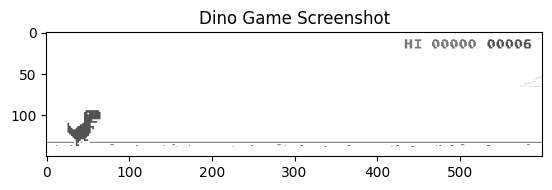

In [74]:
import matplotlib.pyplot as plt
import matplotlib.image as im

plt.title("Dino Game Screenshot")
plt.imshow(im.imread(image_path));

**Gymnasium**
Requirements:
1. Observation space
2. Action space


In [89]:
class DinoDriver:
    def __init__(self,service_url):
        service=Service(service_url)
        options=Options()
        options.add_argument("--no-sandbox")

        self.driver = webdriver.Chrome(service=service,options=options)
        
    def GetDriver(self):
        return self.driver
    
    def StartGame(self):
        try:
            self.driver.get(GAME_URL)
        except:
            pass
            
        element_to_delete = self.driver.find_element(By.ID,"main-message")
        self.driver.execute_script("arguments[0].style.display = 'none'; ",element_to_delete)
        ActionChains(self.driver).send_keys(Keys.ARROW_UP).perform()
        for _ in range(100):
            ActionChains(self.driver).send_keys(Keys.NULL).perform()

    def _close_game(self):
        self.driver.quit()

SERVICE_URL="/usr/local/bin/chromedriver-linux64/chromedriver"
dino_driver = DinoDriver(SERVICE_URL)
dino_driver.StartGame()

In [ ]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from selenium.webdriver import Keys, ActionChains
from typing import Optional

WIDTH_IMAGE=500
HEIGHT_IMAGE=100

class DinoEnv(gym.Env):
    def __init__(self):
        
        self.observation_space = spaces.Box(low=0,high=255, shape=(HEIGHT_IMAGE,WIDTH_IMAGE), dtype=float)
        self.action_space = spaces.Discrete(3) #Jump,Duck,Do nothing


        self.driver=None #driver that controls game
        #Mapping actions to actual keyboard keys
        self._action_to_key = {
            0:ActionChains(driver).send_keys(Keys.ARROW_UP).perform(),
            1:ActionChains(driver).send_keys(Keys.ARROW_DOWN).perform(),
            2:[] #Basically do nothing
        }


    def _get_obs(self):
        """
        using private method, it takes internal observation and converts into required observation/state format

        this according to https://gymnasium.farama.org/introduction/create_custom_env/
        helps us to apply (Do not repeat yourself principle)

        Note this function is not callable from outside the Class as it is a private method/function
        """

        return None
    
    def _get_info(self):
        """
        Returns Time
        """

        return self.clock
    
    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        """
        takes seed, options

        returns State, Info tuple
        """

        super().reset(seed=seed)



    
        #start the game via pressing space
        ActionChains(self.driver).send_keys(Keys.SPACE).perform()

In [5]:
dir(spaces)

['Box',
 'Dict',
 'Discrete',
 'Graph',
 'GraphInstance',
 'MultiBinary',
 'MultiDiscrete',
 'OneOf',
 'Sequence',
 'Space',
 'Text',
 'Tuple',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'box',
 'dict',
 'discrete',
 'flatdim',
 'flatten',
 'flatten_space',
 'graph',
 'multi_binary',
 'multi_discrete',
 'oneof',
 'sequence',
 'space',
 'text',
 'tuple',
 'unflatten',
 'utils']